In [36]:
library(Seurat)
library(tidyverse)
# library(SeuratWrappers)
library(future)
library(ggplot2)
library(SeuratObject)
library(viridis)
# library(ggpubr)
library(scales)
library(presto)
library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)
library(purrr)
library(tidyr)
library(cowplot)
library(RColorBrewer) # For generating high-quality color palettes
library(ggrepel)
library(pals)
library(ggrastr)
library(forcats)

Warning message:
“package ‘RColorBrewer’ was built under R version 4.4.3”
Warning message:
“package ‘ggrepel’ was built under R version 4.4.3”
Warning message:
“package ‘pals’ was built under R version 4.4.3”



Attaching package: ‘pals’


The following objects are masked from ‘package:viridis’:

    cividis, inferno, magma, plasma, turbo, viridis


The following objects are masked from ‘package:viridisLite’:

    cividis, inferno, magma, plasma, turbo, viridis


Warning message:
“package ‘ggrastr’ was built under R version 4.4.3”


# Load Data

In [2]:
# Load Data 
obj <- readRDS('/mnt/18T/chibao/gliomas/data/upstream/scRNA/official/integrated_v5_optimized/adult/obj_full/harmony_integrated_adult_final.rds')
obj

An object of class Seurat 
74637 features across 358244 samples within 2 assays 
Active assay: SCT (36031 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 4 dimensional reductions calculated: pca, umap, harmony, umap.harmony

In [3]:
obj@meta.data |> head()

,orig.ident,nCount_RNA,nFeature_RNA,project_id,orig_sample_id,sample_uid,genome,chemistry,percent.mt,doublet_class,⋯,SCT_snn_res.0.1,SCT_snn_res.0.2,SCT_snn_res.0.4,SCT_snn_res.0.5,SCT_snn_res.0.6,SCT_snn_res.0.7,SCT_snn_res.0.8,SCT_snn_res.1,SCT_snn_res.1.2,seurat_clusters
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACCCAAGTCAAGCG-1,PRJNA1125010,6520,1839,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,6.1196319,singlet,⋯,3,5,33,36,31,31,31,51,49,49
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACCCACATTGCCGG-1,PRJNA1125010,4533,1962,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,14.7804986,singlet,⋯,8,10,6,20,18,21,19,18,32,32
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACGAAAGCTCTGTA-1,PRJNA1125010,50471,7374,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,7.7450417,singlet,⋯,1,4,3,2,1,3,0,25,18,18
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACGAATCCCATAAG-1,PRJNA1125010,41082,7762,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,5.9661165,singlet,⋯,3,5,37,19,21,20,32,35,58,58
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACGCTAGTCACTAC-1,PRJNA1125010,11161,3306,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,0.5286265,singlet,⋯,1,4,3,2,1,3,0,25,18,18
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAAGAACAGTGTCATC-1,PRJNA1125010,2965,1417,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,8.5666105,singlet,⋯,16,23,34,35,37,39,39,41,42,42


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



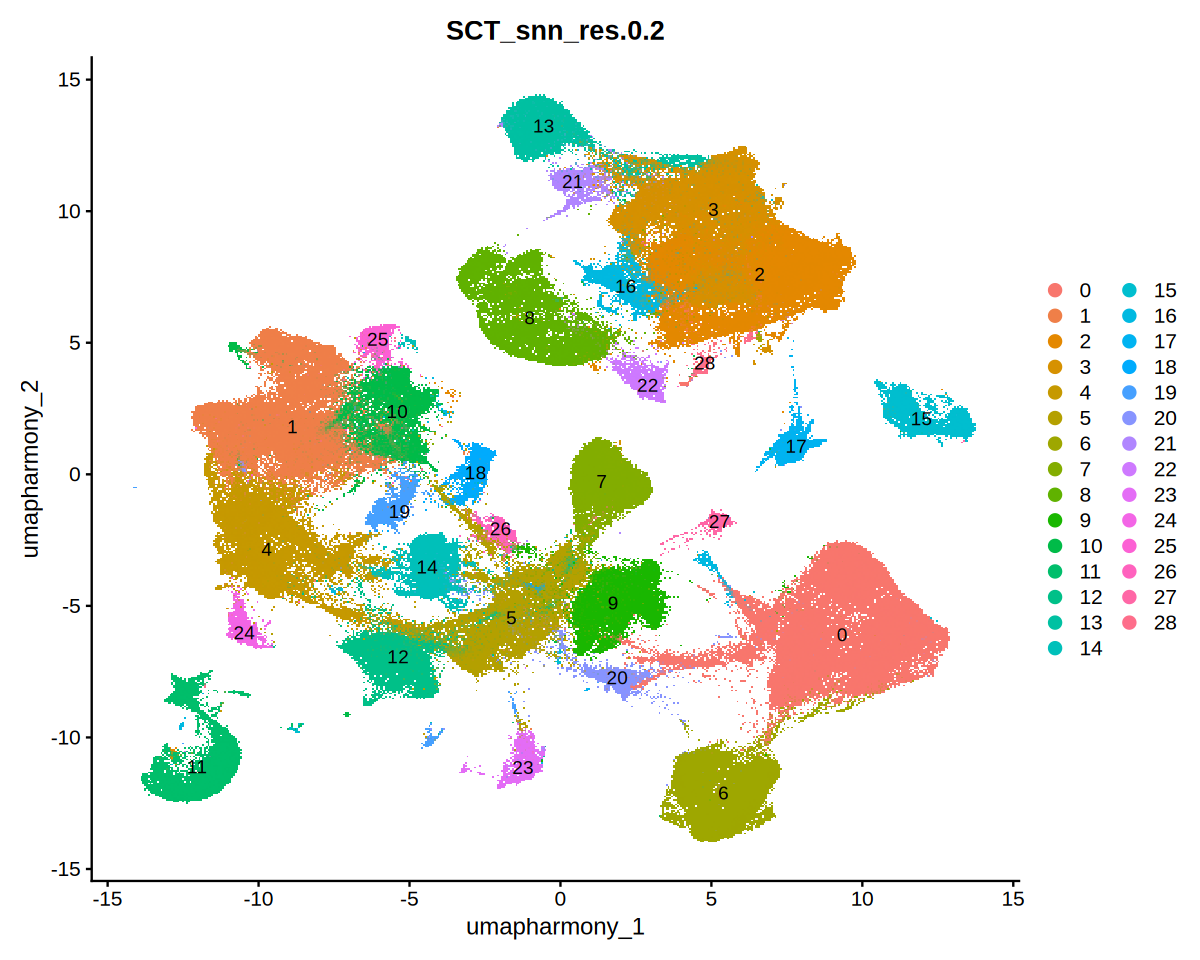

In [4]:
options(repr.plot.width = 10, repr.plot.height = 8)
DimPlot(obj, reduction = 'umap.harmony', group.by = "SCT_snn_res.0.2", label = TRUE)

# Find Markers

In [5]:
obj <- PrepSCTFindMarkers(obj, assay = "SCT", verbose = TRUE)

Found 10 SCT models. Recorrecting SCT counts using minimum median counts: 1731



In [6]:
Idents(obj) <- "SCT_snn_res.0.2"

In [7]:
all_markers <- FindAllMarkers(obj,
                              assay = "SCT",
                              only.pos = TRUE,
                              min.pct = 0.25, 
                              logfc.threshold = 0.25,
                              test.use = "wilcox")
all_markers |> head(2)

Calculating cluster 0



Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10

Calculating cluster 11

Calculating cluster 12

Calculating cluster 13

Calculating cluster 14

Calculating cluster 15

Calculating cluster 16

Calculating cluster 17

Calculating cluster 18

Calculating cluster 19

Calculating cluster 20

Calculating cluster 21

Calculating cluster 22

Calculating cluster 23

Calculating cluster 24

Calculating cluster 25

Calculating cluster 26

Calculating cluster 27

Calculating cluster 28



,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
IL32,0,3.457497,0.743,0.087,0,0,IL32
CD3D,0,3.885836,0.672,0.052,0,0,CD3D


In [8]:
cluster0 <- all_markers %>% filter(cluster == 0) %>% arrange(desc(avg_log2FC))
cluster1 <- all_markers %>% filter(cluster == 1) %>% arrange(desc(avg_log2FC))
cluster2 <- all_markers %>% filter(cluster == 2) %>% arrange(desc(avg_log2FC))
cluster3 <- all_markers %>% filter(cluster == 3) %>% arrange(desc(avg_log2FC))
cluster4 <- all_markers %>% filter(cluster == 4) %>% arrange(desc(avg_log2FC))
cluster5 <- all_markers %>% filter(cluster == 5) %>% arrange(desc(avg_log2FC))
cluster6 <- all_markers %>% filter(cluster == 6) %>% arrange(desc(avg_log2FC))
cluster7 <- all_markers %>% filter(cluster == 7) %>% arrange(desc(avg_log2FC))
cluster8 <- all_markers %>% filter(cluster == 8) %>% arrange(desc(avg_log2FC))
cluster9 <- all_markers %>% filter(cluster == 9) %>% arrange(desc(avg_log2FC))
cluster10 <- all_markers %>% filter(cluster == 10) %>% arrange(desc(avg_log2FC))
cluster11 <- all_markers %>% filter(cluster == 11) %>% arrange(desc(avg_log2FC))
cluster12 <- all_markers %>% filter(cluster == 12) %>% arrange(desc(avg_log2FC))
cluster13 <- all_markers %>% filter(cluster == 13) %>% arrange(desc(avg_log2FC))
cluster14 <- all_markers %>% filter(cluster == 14) %>% arrange(desc(avg_log2FC))
cluster15 <- all_markers %>% filter(cluster == 15) %>% arrange(desc(avg_log2FC))
cluster16 <- all_markers %>% filter(cluster == 16) %>% arrange(desc(avg_log2FC))
cluster17 <- all_markers %>% filter(cluster == 17) %>% arrange(desc(avg_log2FC))
cluster18 <- all_markers %>% filter(cluster == 18) %>% arrange(desc(avg_log2FC))
cluster19 <- all_markers %>% filter(cluster == 19) %>% arrange(desc(avg_log2FC))
cluster20 <- all_markers %>% filter(cluster == 20) %>% arrange(desc(avg_log2FC))
cluster21 <- all_markers %>% filter(cluster == 21) %>% arrange(desc(avg_log2FC))
cluster22 <- all_markers %>% filter(cluster == 22) %>% arrange(desc(avg_log2FC))
cluster23 <- all_markers %>% filter(cluster == 23) %>% arrange(desc(avg_log2FC))
cluster24 <- all_markers %>% filter(cluster == 24) %>% arrange(desc(avg_log2FC))
cluster25 <- all_markers %>% filter(cluster == 25) %>% arrange(desc(avg_log2FC))
cluster26 <- all_markers %>% filter(cluster == 26) %>% arrange(desc(avg_log2FC))
cluster27 <- all_markers %>% filter(cluster == 27) %>% arrange(desc(avg_log2FC))
cluster28 <- all_markers %>% filter(cluster == 28) %>% arrange(desc(avg_log2FC))

In [9]:
cluster17 |> head()
cluster18 |> head()
cluster26 |> head()
cluster27 |> head()


,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
ENSG000002899013,0,3.407252,0.760,0.463,0,17,ENSG00000289901
ENSG000002894744,0,2.863030,0.497,0.279,0,17,ENSG00000289474
MT-ND34,0,2.606751,0.986,0.857,0,17,MT-ND3
MT-ND4L5,0,2.575505,0.577,0.345,0,17,MT-ND4L
MT-ND24,0,2.568090,0.949,0.827,0,17,MT-ND2
MT-ND14,0,2.545220,0.966,0.842,0,17,MT-ND1


,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
GAPDHS,0,8.490409,0.441,0.001,0,18,GAPDHS
LINC00681,0,8.478332,0.515,0.001,0,18,LINC00681
DCT,0,8.194274,0.903,0.012,0,18,DCT
LINC03019,0,8.176847,0.275,0.001,0,18,LINC03019
OCA2,0,7.882561,0.326,0.003,0,18,OCA2
MLANA,0,7.629893,0.909,0.009,0,18,MLANA


,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
NKX2-1,0,9.119799,0.579,0.001,0,26,NKX2-1
FOXA1,0,8.717626,0.487,0.001,0,26,FOXA1
SFTA3,0,8.703043,0.370,0.001,0,26,SFTA3
CEACAM6,0,8.622507,0.513,0.002,0,26,CEACAM6
ENSG00000256615,0,8.551696,0.592,0.003,0,26,ENSG00000256615
SFTA2,0,8.545153,0.402,0.001,0,26,SFTA2


,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
GP9,0,11.37396,0.644,0.001,0,27,GP9
LY6G6F,0,10.99720,0.314,0.000,0,27,LY6G6F
ENSG00000288758,0,10.75347,0.319,0.000,0,27,ENSG00000288758
PPBP,0,10.65146,0.766,0.011,0,27,PPBP
SLC18A2-AS1,0,10.57469,0.322,0.000,0,27,SLC18A2-AS1
CLEC1B,0,10.53773,0.425,0.001,0,27,CLEC1B


# Dot Plot

In [ ]:
# Range
# top_markers <- cluster1$gene[1:15]
top_markers <- c('SYTL3', 'RUNX3', 'PPP1R16B', 'CEMIP2', 'PRKCH', 'CBLB') # 17, 18, 26, 27
# Flatten the markers for DotPlot
markers_genes <- unlist(top_markers)
markers_genes <- make.unique(markers_genes)

# Set factor levels in the order of your original markers vector
markers_genes <- factor(markers_genes, levels = markers_genes)

# Create a mapping from gene -> "Cluster0:Gene" label
label_map <- setNames(
  paste0("Cluster17:", markers_genes), #  17, 18, 26, 27
  markers_genes
)

In [ ]:
options(repr.plot.width = 18, repr.plot.height = 8)

library(Seurat)
library(ggplot2)

DotPlot(obj, features = markers_genes, cluster.idents = TRUE) +
  scale_color_gradient(low = "lightgrey", high = "red") +
  theme_minimal() +
  xlab("Marker Genes") +
  ylab("Cluster ID") +
  ggtitle("Dot Plot of All Marker Genes Across Clusters") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
    axis.text.y = element_text(size = 12),
    plot.title  = element_text(hjust = 0.5)
  ) +
  # Override labels so "CD3D" is displayed as "T_cells:CD3D", etc.
  scale_x_discrete(labels = label_map)


# Feature Plot

In [ ]:
# Create feature plots with custom settings
options(repr.plot.width = 24, repr.plot.height = 6)
FeaturePlot(obj,
            features = c('PDGFRB', 'RGS5', 'TAGLN', 'MYL9'), # 17, 18, 26, 27
            reduction = "umap.harmony",
            ncol = 4, label = TRUE)

# GO Pathway

In [10]:
cluster0_genes <- all_markers |> filter(cluster == 0 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster1_genes <- all_markers |> filter(cluster == 1 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster2_genes <- all_markers |> filter(cluster == 2 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster3_genes <- all_markers |> filter(cluster == 3 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster4_genes <- all_markers |> filter(cluster == 4 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster5_genes <- all_markers |> filter(cluster == 5 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster6_genes <- all_markers |> filter(cluster == 6 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster7_genes <- all_markers |> filter(cluster == 7 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster8_genes <- all_markers |> filter(cluster == 8 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster9_genes <- all_markers |> filter(cluster == 9 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster10_genes <- all_markers |> filter(cluster == 10 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster11_genes <- all_markers |> filter(cluster == 11 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster12_genes <- all_markers |> filter(cluster == 12 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster13_genes <- all_markers |> filter(cluster == 13 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster14_genes <- all_markers |> filter(cluster == 14 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster15_genes <- all_markers |> filter(cluster == 15 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene) 
cluster16_genes <- all_markers |> filter(cluster == 16 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster17_genes <- all_markers |> filter(cluster == 17 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster18_genes <- all_markers |> filter(cluster == 18 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster19_genes <- all_markers |> filter(cluster == 19 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster20_genes <- all_markers |> filter(cluster == 20 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster21_genes <- all_markers |> filter(cluster == 21 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster22_genes <- all_markers |> filter(cluster == 22 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster23_genes <- all_markers |> filter(cluster == 23 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster24_genes <- all_markers |> filter(cluster == 24 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster25_genes <- all_markers |> filter(cluster == 25 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster26_genes <- all_markers |> filter(cluster == 26 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster27_genes <- all_markers |> filter(cluster == 27 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster28_genes <- all_markers |> filter(cluster == 28 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)

In [11]:
# Convert gene symbols to Entrez IDs
entrez_ids <- bitr(
    cluster17_genes, # 17, 18, 26, 27
    fromType = "SYMBOL", 
    toType = "ENTREZID", 
    OrgDb = org.Hs.eg.db)

entrez_ids |> head()

'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(cluster17_genes, fromType = "SYMBOL", toType = "ENTREZID", :
“71.43% of input gene IDs are fail to map...”


,SYMBOL,ENTREZID
,<chr>,<chr>
14,GRID2,2895
15,NRXN1,9378
17,SOX6,55553
18,GRIA2,2891
19,MIR99AHG,388815
20,KAZN,23254


In [12]:
# GO enrichment analysis
go_result <- enrichGO(gene = entrez_ids$ENTREZID,
                                         OrgDb = org.Hs.eg.db,
                                         ont = "BP",  # Biological Process
                                         pAdjustMethod = "BH",
                                         pvalueCutoff = 0.05,
                                         qvalueCutoff = 0.05
                                         )

Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


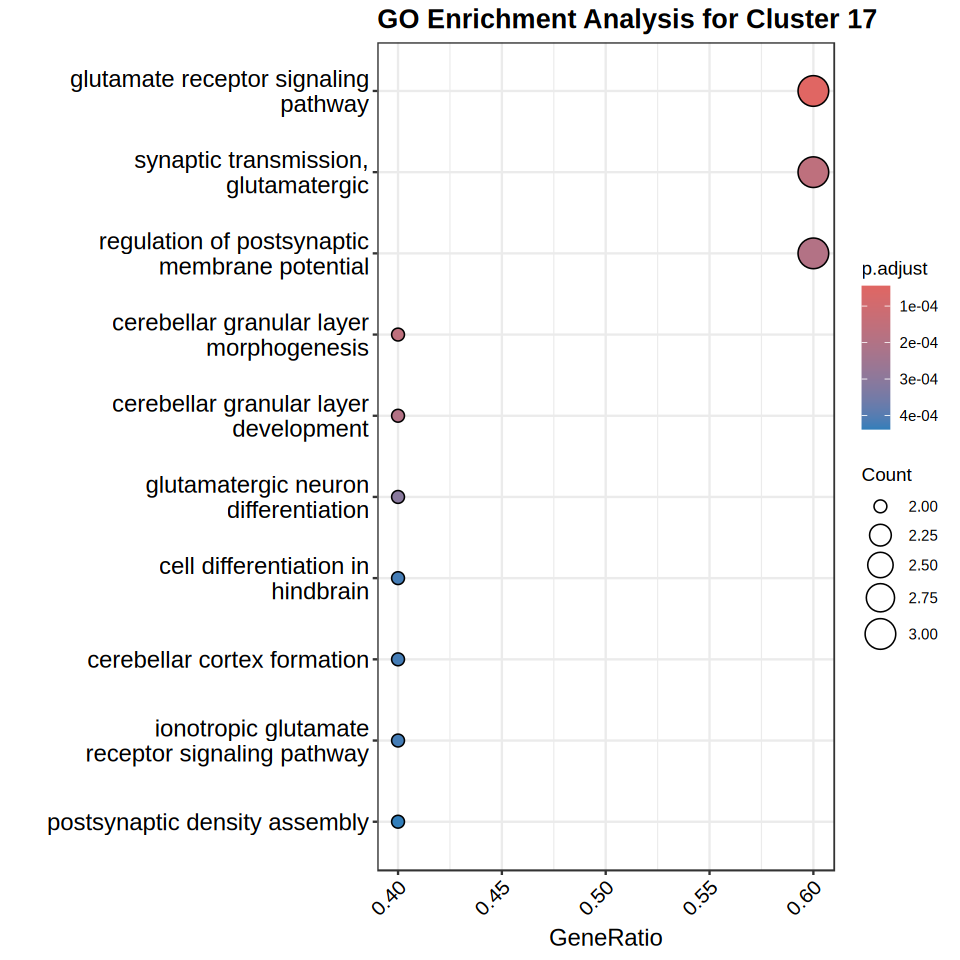

In [13]:
# Visualize GO results
options(repr.plot.width = 8, repr.plot.height = 8)
dotplot(go_result, showCategory = 10) + 
    ggtitle("GO Enrichment Analysis for Cluster 17") +
    theme(plot.title = element_text(size = 16, face = "bold"),
          axis.text.y = element_text(size = 14),
          axis.text.x = element_text(size = 12, angle = 45, hjust = 1),
          axis.title = element_text(size = 14)) +
    scale_size(range = c(3, 8))

# Clean Object

In [14]:
# Create a new object excluding clusters 17, 18 and 26, 27
obj_cleaned <- subset(obj, idents = setdiff(0:28, c(17, 18, 26, 27)))

# Verify the number of clusters
print(table(Idents(obj_cleaned)))


    0     1     2     3     4     5     6     7     8     9    10    11    12 
41660 40480 32459 31603 21614 19467 17517 17402 15845 15558 13459 12744 12488 
   13    14    15    16    19    20    21    22    23    24    25    28 
12299  9208  6662  5099  3628  3296  3286  2818  2679  2436  2187  1004 


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



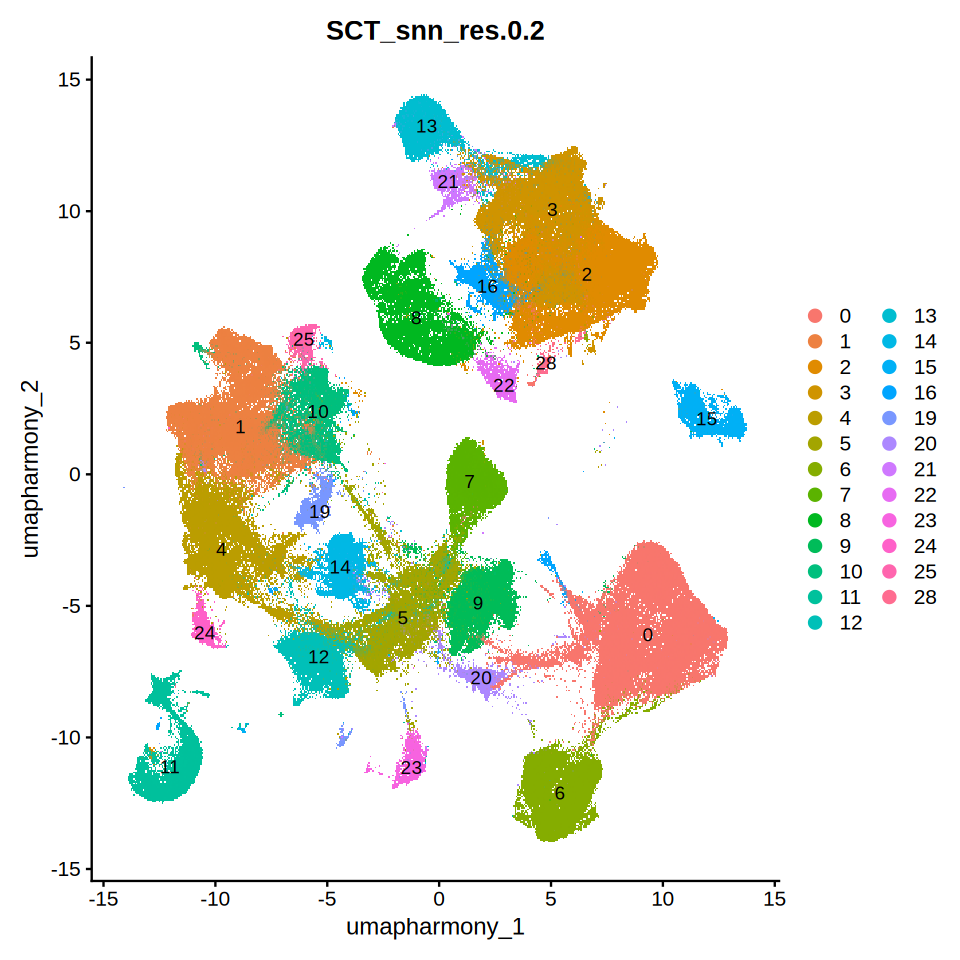

In [21]:
# Obj clean with umap viz 
DimPlot(obj_cleaned, reduction = 'umap.harmony', group.by = 'SCT_snn_res.0.2', label = TRUE)

# Cell Type annotation

In [16]:
obj_cleaned@meta.data <- obj_cleaned@meta.data %>%
    mutate(general_cell_type = case_when(
        SCT_snn_res.0.2 %in% c(13, 21, 16, 3, 2, 8, 22, 28) ~ "Myeloid",
        SCT_snn_res.0.2 %in% c(15) ~ "B_cell",        
        SCT_snn_res.0.2 %in% c(0, 20, 9, 6) ~ "TILs",
        SCT_snn_res.0.2 %in% c(11) ~ "Mature_Oligodendrocyte",
        SCT_snn_res.0.2 %in% c(19) ~ "Pericyte",
        SCT_snn_res.0.2 %in% c(23) ~ "Endothelial",
        SCT_snn_res.0.2 %in% c(7) ~ "CTAs",
        SCT_snn_res.0.2 %in% c(1) ~ "Astrocyte_like",
        SCT_snn_res.0.2 %in% c(4, 14, 24) ~ "OPC_like",
        SCT_snn_res.0.2 %in% c(5, 12) ~ "NPC_like",        
        SCT_snn_res.0.2 %in% c(10, 25) ~ "Mesenchymal_like",
        TRUE ~ NA_character_
    ))

head(obj_cleaned@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,project_id,orig_sample_id,sample_uid,genome,chemistry,percent.mt,doublet_class,⋯,SCT_snn_res.0.2,SCT_snn_res.0.4,SCT_snn_res.0.5,SCT_snn_res.0.6,SCT_snn_res.0.7,SCT_snn_res.0.8,SCT_snn_res.1,SCT_snn_res.1.2,seurat_clusters,general_cell_type
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<chr>
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACCCAAGTCAAGCG-1,PRJNA1125010,6520,1839,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,6.1196319,singlet,⋯,5,33,36,31,31,31,51,49,49,NPC_like
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACCCACATTGCCGG-1,PRJNA1125010,4533,1962,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,14.7804986,singlet,⋯,10,6,20,18,21,19,18,32,32,Mesenchymal_like
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACGAAAGCTCTGTA-1,PRJNA1125010,50471,7374,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,7.7450417,singlet,⋯,4,3,2,1,3,0,25,18,18,OPC_like
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACGAATCCCATAAG-1,PRJNA1125010,41082,7762,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,5.9661165,singlet,⋯,5,37,19,21,20,32,35,58,58,NPC_like
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACGCTAGTCACTAC-1,PRJNA1125010,11161,3306,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,0.5286265,singlet,⋯,4,3,2,1,3,0,25,18,18,OPC_like
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAAGAACAGTGTCATC-1,PRJNA1125010,2965,1417,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,8.5666105,singlet,⋯,23,34,35,37,39,39,41,42,42,Endothelial


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



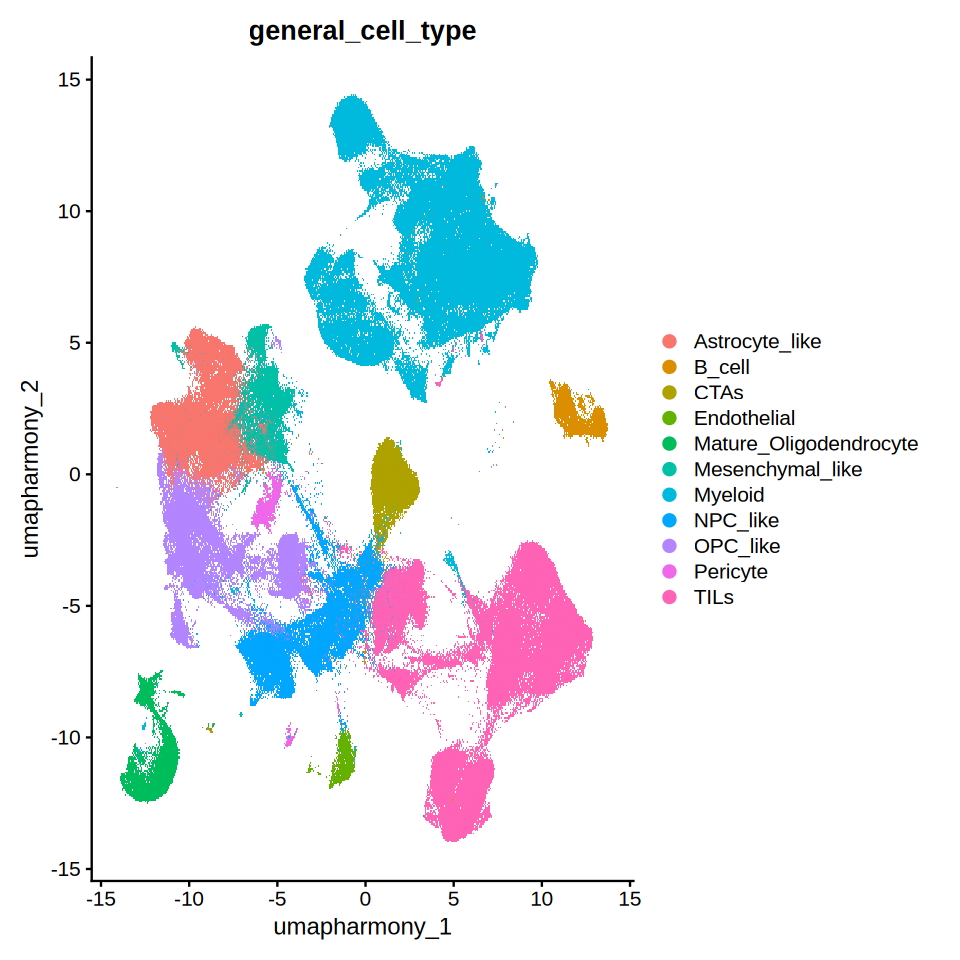

In [22]:
DimPlot(obj_cleaned, reduction = "umap.harmony", group.by = 'general_cell_type', label = FALSE)

In [23]:
obj_cleaned$general_cell_type |> unique()

[1] "NPC_like"               "Mesenchymal_like"       "OPC_like"              
 [4] "Endothelial"            "Astrocyte_like"         "TILs"                  
 [7] "Myeloid"                "Mature_Oligodendrocyte" "CTAs"                  
[10] "Pericyte"               "B_cell"

In [24]:
Idents(obj_cleaned) <- "general_cell_type"

In [26]:
# Get all unique cell types from the specified metadata column
cell_types <- levels(factor(obj_cleaned$general_cell_type))
num_cell_types <- length(cell_types)

message(paste("Found", num_cell_types, "cell types in 'general_cell_type' metadata."))

Found 11 cell types in 'general_cell_type' metadata.



In [27]:
polychrome_11 <- c(
    "#E41A1C", "#377EB8", "#4DAF4A", "#984EA3", "#FF7F00", "#F781BF",
    "#8DD3C7", "#BEBADA", "#FB8072", "#80B1D3", "#FDB462")

In [28]:
# Create the final color vector
if (num_cell_types > length(polychrome_11)) {
    # If there are more cell types than predefined colors, warn the user
    # and generate the remaining colors. Manual curation is best here.
    warning(paste("Number of cell types (", num_cell_types, ") exceeds the 11 predefined colors.
                   Generating extra colors via colorRampPalette.
                   For true publication quality, manual curation of this palette is recommended."))
    color_ramp <- colorRampPalette(polychrome_11)
    custom_colors <- color_ramp(num_cell_types)
} else {
    # Otherwise, just take the first N colors from the palette
    custom_colors <- polychrome_11[1:num_cell_types]
}

In [29]:
# Create the named vector to map colors to cell types explicitly
# This ensures consistency in plotting
names(custom_colors) <- cell_types

message("Custom color palette defined and mapped to cell types.")

Custom color palette defined and mapped to cell types.



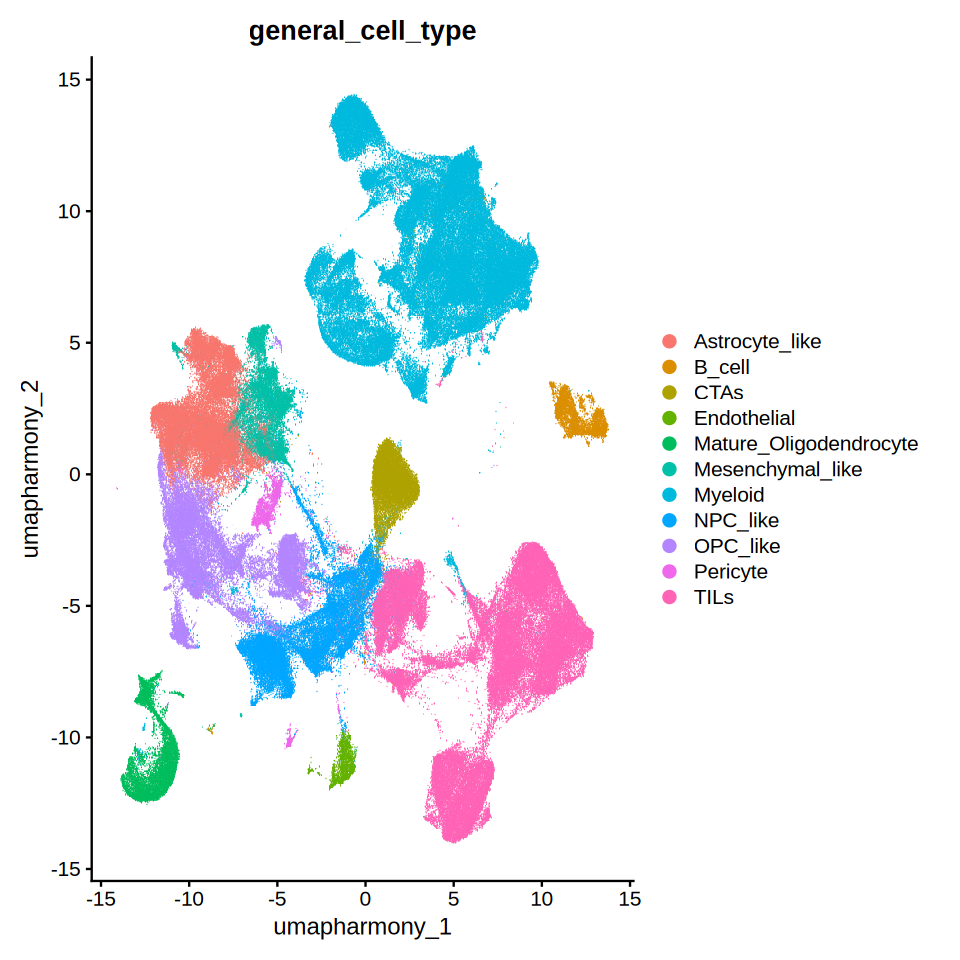

In [30]:
# Generate the base DimPlot
# We use Seurat's built-in rasterization, which is efficient
p_base <- DimPlot(
    obj_cleaned,
    reduction = "umap.harmony",   # Requirement: Use 'umap.harmony'
    group.by = "general_cell_type", # Requirement: Group by cell type
    
    # Data Representation Requirements
    label = FALSE,                # Requirement: No text labels on plot
    pt.size = 1.5,                # Requirement: Small point size for 350k cells
    
    # Rasterization Requirement
    raster = TRUE,                # Requirement: Rasterize point layer
    raster.dpi = c(1024, 1024)    # High DPI for crisp points
)

p_base

Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


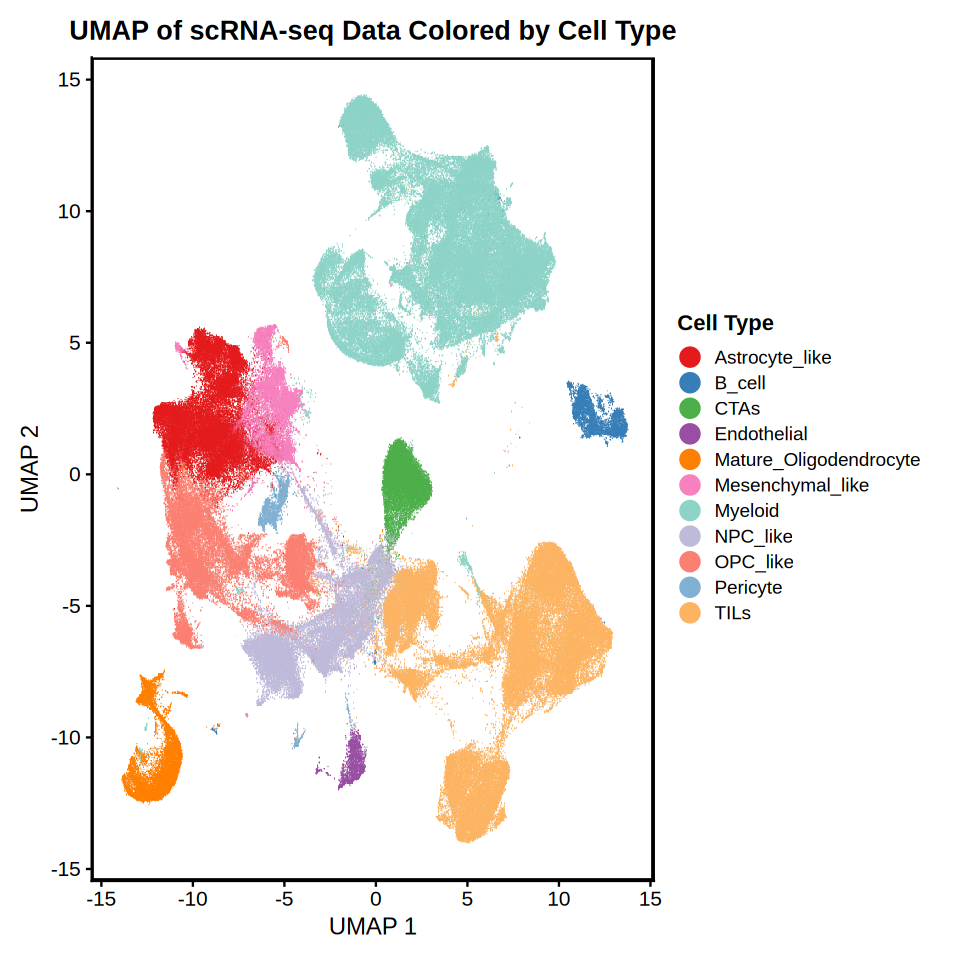

In [37]:
p_formatted <- p_base +
    # Apply the custom, named color palette
    scale_color_manual(values = custom_colors) +

    # Set correct axis and legend titles
    labs(
        x = "UMAP 1",
        y = "UMAP 2",
        title = "UMAP of scRNA-seq Data Colored by Cell Type",
        color = "Cell Type" # Renames the legend title
    ) +

    # Apply a minimal, publication-ready theme
    theme_cowplot() +
    
    # Theme adjustments for a clean, final look
    theme(
        # Set text sizes
        axis.text = element_text(size = 12, color = "black"),
        axis.title = element_text(size = 14, color = "black"),
        legend.text = element_text(size = 11, color = "black"),
        plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
        legend.title = element_text(size = 13, face = "bold", color = "black"),
        
        # Requirement: Remove all background gridlines
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        
        # Requirement: Add a clean panel border
        panel.border = element_rect(color = "black", fill = NA, size = 1),
        
        # Ensure plot axis lines are visible
        axis.line = element_line(color = "black")
    ) +
    
    # Requirement: Increase legend point size for clarity
    guides(color = guide_legend(
        override.aes = list(size = 5),
        ncol = 1 # Ensure legend is a single vertical column
    ))

p_formatted

In [ ]:
saveRDS(obj_cleaned, '/mnt/18T/chibao/gliomas/data_official/01_integrated_obj/01_integrated_annotated_official.rds')